This is a companion notebook for the book [Deep Learning with Python, Second Edition](https://www.manning.com/books/deep-learning-with-python-second-edition?a_aid=keras&a_bid=76564dff). For readability, it only contains runnable code blocks and section titles, and omits everything else in the book: text paragraphs, figures, and pseudocode.

**If you want to be able to follow what's going on, I recommend reading the notebook side by side with your copy of the book.**

This notebook was generated for TensorFlow 2.6.

# Introduction to Keras and TensorFlow

## What's TensorFlow?

## What's Keras?

## Keras and TensorFlow: A brief history

## Setting up a deep-learning workspace

### Jupyter notebooks: The preferred way to run deep-learning experiments

### Using Colaboratory

#### First steps with Colaboratory

#### Installing packages with pip

#### Using the GPU runtime

## First steps with TensorFlow

#### Constant tensors and variables

**All-ones or all-zeros tensors**

In [9]:
import tensorflow as tf
x = tf.ones(shape=(2,1))
print(x)

tf.Tensor(
[[1.]
 [1.]], shape=(2, 1), dtype=float32)


In [11]:
x = tf.zeros(shape=(2,1))
print(x)

tf.Tensor(
[[0.]
 [0.]], shape=(2, 1), dtype=float32)


**Random tensors**

In [14]:
x = tf.random.normal(shape=(3,1), mean=0., stddev=1.)
print(x)

tf.Tensor(
[[-0.33290684]
 [ 0.04827305]
 [ 1.0719283 ]], shape=(3, 1), dtype=float32)


In [16]:
x = tf.random.uniform(shape=(3,1), minval=0., maxval=1.)
print(x)

tf.Tensor(
[[4.336834e-04]
 [5.214603e-01]
 [7.180848e-01]], shape=(3, 1), dtype=float32)


**NumPy arrays are assignable**

In [19]:
import numpy as np
x = np.ones(shape=(2,2))
x[0,0]=0

**Creating a TensorFlow variable**

In [22]:
v = tf.Variable(initial_value=tf.random.normal(shape=(3,1)))
print(v)

<tf.Variable 'Variable:0' shape=(3, 1) dtype=float32, numpy=
array([[-0.39467603],
       [ 0.1307222 ],
       [-2.3043747 ]], dtype=float32)>


**Assigning a value to a TensorFlow variable**

In [25]:
v.assign(tf.ones((3,1)))

<tf.Variable 'UnreadVariable' shape=(3, 1) dtype=float32, numpy=
array([[1.],
       [1.],
       [1.]], dtype=float32)>

**Assigning a value to a subset of a TensorFlow variable**

In [28]:
v[0,0].assign(3.)

<tf.Variable 'UnreadVariable' shape=(3, 1) dtype=float32, numpy=
array([[3.],
       [1.],
       [1.]], dtype=float32)>

**Using `assign_add`**

In [31]:
v.assign_add(tf.ones((3,1)))

<tf.Variable 'UnreadVariable' shape=(3, 1) dtype=float32, numpy=
array([[4.],
       [2.],
       [2.]], dtype=float32)>

#### Tensor operations: Doing math in TensorFlow

**A few basic math operations**

In [35]:
a = tf.ones((2,2))
b = tf.square(a)
c = tf.sqrt(a)
d = b+c
e = tf.matmul(a,b)
e *= d

#### A second look at the GradientTape API

**Using the `GradientTape`**

In [39]:
input_var = tf.Variable(initial_value=3.)
with tf.GradientTape() as tape:
    result = tf.square(input_var)
gradient = tape.gradient(result, input_var)
gradient

<tf.Tensor: shape=(), dtype=float32, numpy=6.0>

**Using `GradientTape` with constant tensor inputs**

In [42]:
input_const = tf.constant(3.)
with tf.GradientTape() as tape:
    tape.watch(input_const)
    result = tf.square(input_const)
gradient = tape.gradient(result, input_const)
gradient

<tf.Tensor: shape=(), dtype=float32, numpy=6.0>

**Using nested gradient tapes to compute second-order gradients**

In [45]:
time = tf.Variable(0.)
with tf.GradientTape() as outer_tape:
    with tf.GradientTape() as inner_tape:
        position = 4.9 * time ** 2
    speed = inner_tape.gradient(position, time)
acceleration = outer_tape.gradient(speed, time)

#### An end-to-end example: A linear classifier in pure TensorFlow

**Generating two classes of random points in a 2D plane**

In [49]:
import numpy as np

num_samples_per_class = 1000
negative_samples = np.random.multivariate_normal(mean=[0,3], cov=[[1,0.5], [0.5,1]], size=num_samples_per_class)

positive_samples = np.random.multivariate_normal(mean=[3,0], cov=[[1,0.5],[0.5,1]], size=num_samples_per_class)

**Stacking the two classes into an array with shape (2000, 2)**

In [52]:
inputs = np.vstack((negative_samples, positive_samples)).astype(np.float32)
inputs

array([[-1.7084281 ,  2.4150007 ],
       [ 0.32362363,  2.5061388 ],
       [ 1.4986017 ,  3.7356539 ],
       ...,
       [ 3.08727   , -1.2240088 ],
       [ 2.4620974 ,  0.8508468 ],
       [ 3.057191  , -0.80805486]], dtype=float32)

**Generating the corresponding targets (0 and 1)**

In [55]:
inputs[:,0]

array([-1.7084281 ,  0.32362363,  1.4986017 , ...,  3.08727   ,
        2.4620974 ,  3.057191  ], dtype=float32)

In [57]:
targets = np.vstack((np.zeros((num_samples_per_class, 1), dtype="float32"),
                     np.ones((num_samples_per_class, 1), dtype="float32")))
targets

array([[0.],
       [0.],
       [0.],
       ...,
       [1.],
       [1.],
       [1.]], dtype=float32)

**Plotting the two point classes**

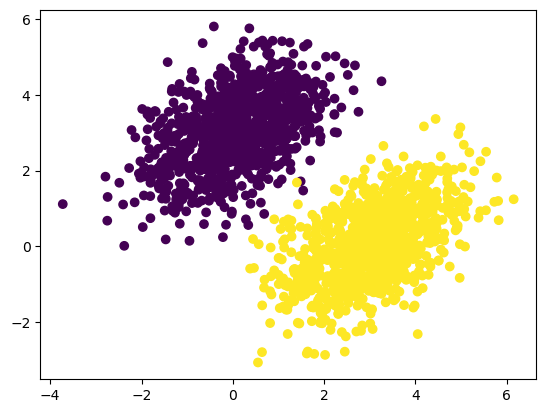

In [60]:
import matplotlib.pyplot as plt
plt.scatter(inputs[:,0], inputs[:,1], c=targets[:,0])
plt.show()

**Creating the linear classifier variables**

In [63]:
input_dim = 2
output_dim = 1
W = tf.Variable(initial_value=tf.random.uniform(shape=(input_dim, output_dim)))
b = tf.Variable(initial_value=tf.zeros(shape=(output_dim,)))

**The forward pass function**

In [66]:
def model(inputs):
    return tf.matmul(inputs, W) + b

**The mean squared error loss function**

In [69]:
def square_loss(targets, predictions):
    per_sample_losses = tf.square(targets - predictions)
    return tf.reduce_mean(per_sample_losses)

**The training step function**

In [72]:
learning_rate = 0.1
def training_step(inputs, targets):
    with tf.GradientTape() as tape:
        predictions = model(inputs)
        loss = square_loss(targets, predictions)
    grad_loss_wrt_W, grad_loss_wrt_b = tape.gradient(loss, [W,b])
    W.assign_sub(grad_loss_wrt_W * learning_rate)
    b.assign_sub(grad_loss_wrt_b * learning_rate)
    return loss

**The batch training loop**

In [75]:
for step in range(40):
    loss = training_step(inputs, targets)
    print(f"Loss at step {step}: {loss:.4f}")

Loss at step 0: 0.5077
Loss at step 1: 0.1001
Loss at step 2: 0.0836
Loss at step 3: 0.0772
Loss at step 4: 0.0727
Loss at step 5: 0.0688
Loss at step 6: 0.0652
Loss at step 7: 0.0619
Loss at step 8: 0.0589
Loss at step 9: 0.0561
Loss at step 10: 0.0536
Loss at step 11: 0.0513
Loss at step 12: 0.0491
Loss at step 13: 0.0472
Loss at step 14: 0.0453
Loss at step 15: 0.0437
Loss at step 16: 0.0422
Loss at step 17: 0.0408
Loss at step 18: 0.0395
Loss at step 19: 0.0383
Loss at step 20: 0.0372
Loss at step 21: 0.0362
Loss at step 22: 0.0353
Loss at step 23: 0.0345
Loss at step 24: 0.0337
Loss at step 25: 0.0330
Loss at step 26: 0.0324
Loss at step 27: 0.0318
Loss at step 28: 0.0312
Loss at step 29: 0.0307
Loss at step 30: 0.0303
Loss at step 31: 0.0298
Loss at step 32: 0.0294
Loss at step 33: 0.0291
Loss at step 34: 0.0288
Loss at step 35: 0.0285
Loss at step 36: 0.0282
Loss at step 37: 0.0279
Loss at step 38: 0.0277
Loss at step 39: 0.0275


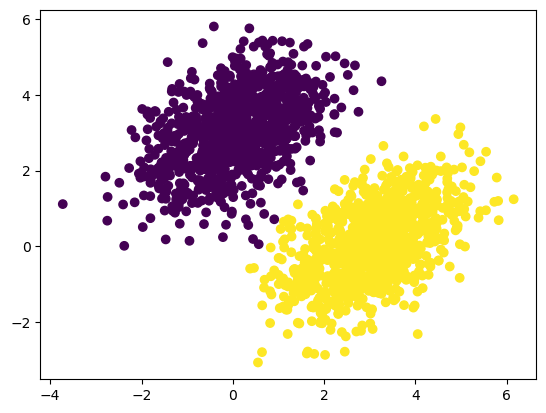

In [77]:
predictions = model(inputs)
plt.scatter(inputs[:,0], inputs[:,1], c=predictions[:,0]>0.5)
plt.show()

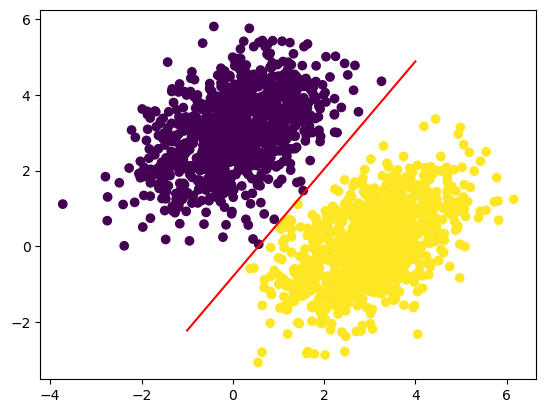

In [79]:
x = np.linspace(-1,4,100)
y = -W[0] / W[1] * x + (0.5 - b) / W[1]
plt.plot(x, y, "-r")
plt.scatter(inputs[:,0], inputs[:,1], c=predictions[:,0]>0.5)

## Anatomy of a neural network: Understanding core Keras APIs

### Layers: The building blocks of deep learning

#### The base Layer class in Keras

**A `Dense` layer implemented as a `Layer` subclass**

In [85]:
from tensorflow import keras
class SimpleDense(keras.layers.Layer):
    def __init__(self, units, activation=None):
        super().__init__()
        self.units = units
        self.activation = activation
    def build(self, input_shape):
        input_dim = input_shape[-1]
        self.W = self.add_weight(shape=(input_dim, self.units), initializer="random_normal")
        self.b = self.add_weight(shape=(self.units,), initializer="zeros")
    def call(self, inputs):
        y = tf.matmul(inputs, self.W) + self.b
        if self.activation is not None:
            y = self.activation(y)
        return y

In [87]:
my_dense = SimpleDense(units=32, activation=tf.nn.relu)
input_tensor = tf.ones(shape=(2, 784))
output_tensor = my_dense(input_tensor)
print(output_tensor.shape)

(2, 32)


#### Automatic shape inference: Building layers on the fly

In [90]:
from tensorflow.keras import layers
layer = layers.Dense(32, activation="relu")

In [92]:
from tensorflow.keras import models
from tensorflow.keras import layers
model = models.Sequential([
    layers.Dense(32, activation="relu"),
    layers.Dense(32)
])

In [94]:
model = keras.Sequential([
    SimpleDense(32, activation="relu"),
    SimpleDense(64, activation="relu"),
    SimpleDense(32, activation="relu"),
    SimpleDense(10, activation="softmax")
])

### From layers to models

### The "compile" step: Configuring the learning process

In [104]:
model = keras.Sequential([keras.layers.Dense(1)])
model.compile(optimizer="rmsprop",
              loss="mean_squared_error",
              metrics=["accuracy"])

In [102]:
model.compile(optimizer=keras.optimizers.RMSprop(),
              loss=keras.losses.MeanSquaredError(),
              metrics=[keras.metrics.BinaryAccuracy()])

### Picking a loss function

### Understanding the fit() method

**Calling `fit()` with NumPy data**

In [106]:
history = model.fit(
    inputs,
    targets,
    epochs=5,
    batch_size=128
)

Epoch 1/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9983 - loss: 6.3036  
Epoch 2/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9976 - loss: 5.9286 
Epoch 3/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9987 - loss: 5.6822 
Epoch 4/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9981 - loss: 5.3654 
Epoch 5/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9991 - loss: 5.1649 


In [108]:
history.history

{'accuracy': [0.9984999895095825,
  0.9984999895095825,
  0.9984999895095825,
  0.9984999895095825,
  0.9984999895095825],
 'loss': [6.122035980224609,
  5.836209774017334,
  5.594613075256348,
  5.362034320831299,
  5.1349287033081055]}

### Monitoring loss and metrics on validation data

**Using the `validation_data` argument**

In [118]:
model = keras.Sequential([keras.layers.Dense(1)])
model.compile(optimizer=keras.optimizers.RMSprop(learning_rate=0.1),
              loss=keras.losses.MeanSquaredError(),
              metrics=[keras.metrics.BinaryAccuracy()])
indices_permutation = np.random.permutation(len(inputs))
shuffled_inputs = inputs[indices_permutation]
shuffled_targets = inputs[indices_permutation]

num_validation_samples = int(0.3*len(inputs))
val_inputs = shuffled_inputs[:num_validation_samples]
val_targets = shuffled_targets[:num_validation_samples]
training_inputs = shuffled_inputs[num_validation_samples:]
training_targets = shuffled_targets[num_validation_samples:]
model.fit(
    training_inputs,
    training_targets,
    epochs=5,
    batch_size=16,
    validation_data=(val_inputs, val_targets)
)

Epoch 1/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.0000e+00 - loss: 7.0665 - val_binary_accuracy: 0.0000e+00 - val_loss: 2.5355
Epoch 2/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.0000e+00 - loss: 2.4787 - val_binary_accuracy: 0.0000e+00 - val_loss: 2.5338
Epoch 3/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.0000e+00 - loss: 2.5043 - val_binary_accuracy: 0.0000e+00 - val_loss: 2.6101
Epoch 4/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.0000e+00 - loss: 2.4597 - val_binary_accuracy: 0.0000e+00 - val_loss: 2.7091
Epoch 5/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.0000e+00 - loss: 2.4718 - val_binary_accuracy: 0.0000e+00 - val_loss: 2.5405


### Inference: Using a model after training

In [120]:
predictions = model.predict(val_inputs, batch_size=128)
print(predictions[:10])

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
[[2.803965  ]
 [1.527025  ]
 [0.86804485]
 [2.4120982 ]
 [2.2517602 ]
 [1.4227421 ]
 [2.9250305 ]
 [0.05744409]
 [1.4484993 ]
 [2.753642  ]]


## Summary